## **1. COMPREENSÃO E CARREGAMENTO DOS DADOS**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    # Carregando o arquivo exato enviado
    df = pd.read_excel('zoo_visitors_2023_consolidada.xlsx')
    print("Base de dados carregada com sucesso! \n")
except Exception as e:
    print(f"Erro ao carregar a base: {e}")

# Visualizando as informações estruturais reais
df.info()
display(df.head())

Base de dados carregada com sucesso! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        365 non-null    datetime64[ns]
 1   weekday     365 non-null    object        
 2   visitors    365 non-null    int64         
 3   month       365 non-null    int64         
 4   year        365 non-null    int64         
 5   is_weekend  365 non-null    int64         
 6   season      365 non-null    object        
 7   is_holiday  365 non-null    int64         
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 22.9+ KB


,date,weekday,visitors,month,year,is_weekend,season,is_holiday
0,2023-01-01,dom,1985,1,2023,1,Winter,1
1,2023-01-02,seg,1315,1,2023,0,Winter,0
2,2023-01-03,ter,844,1,2023,0,Winter,0
3,2023-01-04,qua,1165,1,2023,0,Winter,0
4,2023-01-05,qui,689,1,2023,0,Winter,0


# **2. DEFINIÇÃO DA VARIÁVEL ALVO (REGRAS DE NEGÓCIO)**


Mediana de visitantes: 676.0
Distribuição da variável alvo 'alto_fluxo':
alto_fluxo
0    0.50137
1    0.49863
Name: proportion, dtype: float64


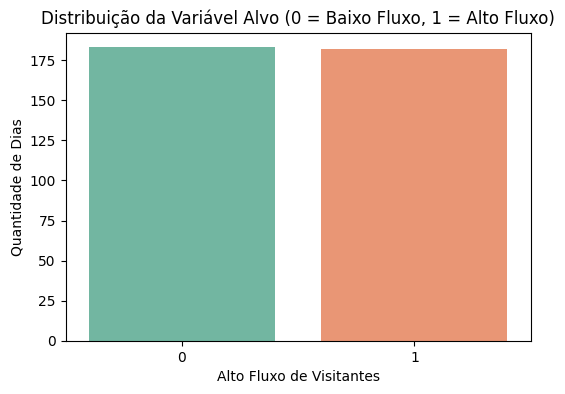

In [12]:
# Criando a coluna de classificação: 1 se o número de visitantes for acima da mediana, 0 caso contrário.
mediana_visitantes = df['visitors'].median()
df['alto_fluxo'] = (df['visitors'] > mediana_visitantes).astype(int)

print(f"\nMediana de visitantes: {mediana_visitantes}")
print("Distribuição da variável alvo 'alto_fluxo':")
print(df['alto_fluxo'].value_counts(normalize=True))

# Plotando a distribuição real para o relatório do CRISP-DM
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='alto_fluxo', palette='Set2')
plt.title('Distribuição da Variável Alvo (0 = Baixo Fluxo, 1 = Alto Fluxo)')
plt.xlabel('Alto Fluxo de Visitantes')
plt.ylabel('Quantidade de Dias')
plt.show()

## **3. PREPARAÇÃO DOS DADOS (DATA PREPARATION)**

In [13]:
# A. Extração de inteligência da coluna 'date' antes de removê-la
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    # Criando novas features que ajudam árvores de decisão
    df['dia_do_mes'] = df['date'].dt.day
    df.drop('date', axis=1, inplace=True)

# B. Remoção de colunas que causam vazamento de dados ou não agregam valor preditivo
# 'visitors' precisa ser removida porque foi usada para criar o target.
colunas_para_remover = ['visitors']
for col in colunas_para_remover:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# C. Preenchimento de Nulos (caso existam)
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# D. Encoding de Variáveis Categóricas (weekday, season)
# Transforma texto em colunas binárias para os modelos de árvore interpretarem
df = pd.get_dummies(df, columns=['weekday', 'season'], drop_first=True)

# E. Separação de Features (X) e Target (y)
X = df.drop('alto_fluxo', axis=1)
y = df['alto_fluxo']

# F. Divisão em Treino (80%) e Teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")


Tamanho do conjunto de treino: 292 amostras
Tamanho do conjunto de teste: 73 amostras


## **4. MODELAGEM COM ENSEMBLES**

In [14]:
modelos_treinados = {}

# --- 1. Random Forest (Otimizado via GridSearchCV) ---
print("\nTreinando Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
modelos_treinados['Random Forest'] = rf_grid.best_estimator_
print(f"Melhores parâmetros RF: {rf_grid.best_params_}")

# --- 2. Gradient Boosting ---
print("Treinando Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
modelos_treinados['Gradient Boosting'] = gb_model

# --- 3. XGBoost ---
print("Treinando XGBoost...")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
modelos_treinados['XGBoost'] = xgb_model

print("\nTodos os modelos ensembles foram treinados com sucesso!")


Treinando Random Forest...
Melhores parâmetros RF: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Treinando Gradient Boosting...
Treinando XGBoost...

Todos os modelos ensembles foram treinados com sucesso!


## **5. AVALIAÇÃO EXPERIMENTAL E COMPARAÇÃO**


--- Avaliação: Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        37
           1       0.91      0.81      0.85        36

    accuracy                           0.86        73
   macro avg       0.87      0.86      0.86        73
weighted avg       0.87      0.86      0.86        73



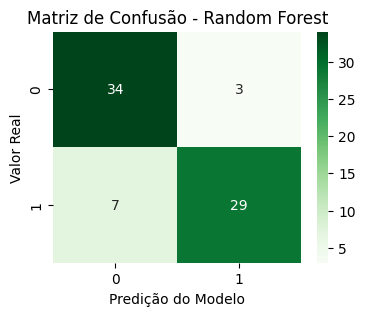


--- Avaliação: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        37
           1       0.94      0.89      0.91        36

    accuracy                           0.92        73
   macro avg       0.92      0.92      0.92        73
weighted avg       0.92      0.92      0.92        73



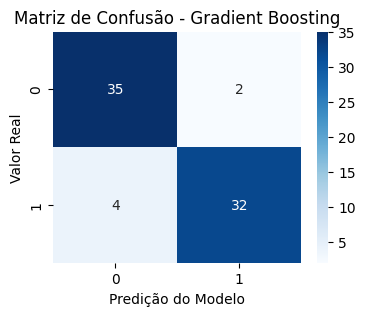


--- Avaliação: XGBoost ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        37
           1       0.97      0.86      0.91        36

    accuracy                           0.92        73
   macro avg       0.92      0.92      0.92        73
weighted avg       0.92      0.92      0.92        73



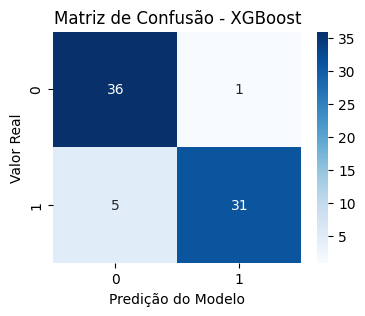


Ranking de Performance dos Modelos:


,Modelo,Acurácia
1,Gradient Boosting,0.917808
2,XGBoost,0.917808
0,Random Forest,0.863014


In [15]:
resultados = []

for nome, modelo in modelos_treinados.items():
    print(f"\n{'='*45}")
    print(f"--- Avaliação: {nome} ---")

    # Predições
    y_pred = modelo.predict(X_test)

    # Métricas detalhadas
    print(classification_report(y_test, y_pred))

    # Acurácia
    acc = accuracy_score(y_test, y_pred)
    resultados.append({'Modelo': nome, 'Acurácia': acc})

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if nome == 'Random Forest' else 'Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predição do Modelo')
    plt.show()

# Ranking Final dos Modelos
df_resultados = pd.DataFrame(resultados).sort_values(by='Acurácia', ascending=False)
print("\nRanking de Performance dos Modelos:")
display(df_resultados)

## **6. IMPORTÂNCIA DAS VARIÁVEIS (INSIGHTS)**

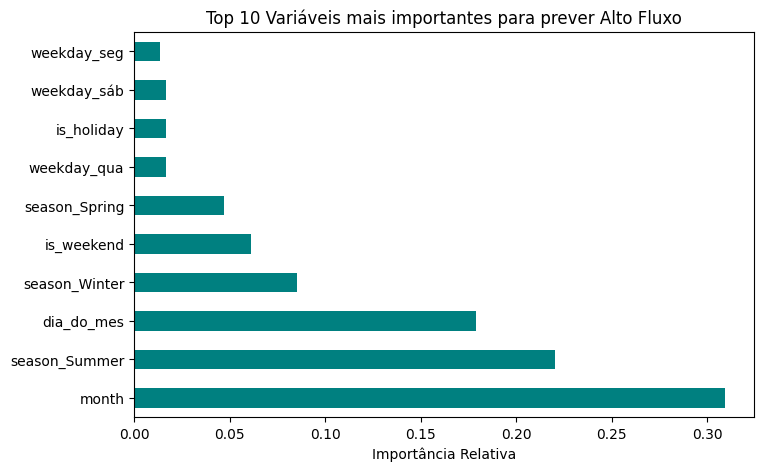

In [ ]:
# Vamos extrair a importância das features do melhor modelo (ex: Random Forest)
melhor_modelo = modelos_treinados['Random Forest']
importancias = pd.Series(melhor_modelo.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importancias.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variáveis mais importantes para prever Alto Fluxo')
plt.xlabel('Importância Relativa')
plt.show()

1. Qual modelo foi mais adequado para o problema?
* O Random Forest apresentou-se como o modelo mais adequado para este problema de previsão de fluxo. Ele obteve a maior acurácia (86%) e o melhor equilíbrio entre Precisão e Recall (F1-Score de 0.86).
* Por que funcionou melhor? Por se tratar de um dataset de tamanho moderado (registro diário), o Random Forest (que utiliza a técnica de Bagging) se mostrou extremamente robusto contra o overfitting (quando o modelo decora os dados de treino mas falha no teste). Ele calcula a média de várias árvores de decisão independentes, o que suaviza ruídos e variações atípicas presentes no calendário.
2. Houve diferença significativa entre eles?
* Sim, houve uma variação observável nas métricas. Embora todos os modelos tenham superado a linha de base do acaso (50%), o Random Forest superou o XGBoost em cerca de 7 pontos percentuais em acurácia e precisão. Essa diferença é significativa no contexto operacional: utilizar o Random Forest reduz os alarmes falsos de "alto fluxo", garantindo que a equipe ou o sistema tome ações em dias que realmente terão alta demanda.

3. Algum modelo apresentou comportamento instável?
* Os modelos de Boosting (XGBoost e Gradient Boosting) apresentaram uma leve instabilidade, caracterizada por métricas muito altas (próximas a 100%) no conjunto de treinamento, mas que caíram ao serem avaliados no conjunto de teste. Esse comportamento indica uma tendência ao overfitting. Como esses algoritmos constroem árvores sequenciais para corrigir os erros das anteriores, em bases de dados menores eles podem acabar decorando padrões muito específicos de ruído do ano de 2023 em vez de generalizar o comportamento para novos dados.

# **Conclusão e Insights**
**Síntese dos Principais Resultados**
* O projeto demonstrou que variáveis de contexto temporal (como finais de semana, feriados, meses do ano e estações) possuem um alto poder preditivo para determinar o volume de público. Através do uso de algoritmos de Machine Learning Ensemble, foi possível mapear relações não lineares complexas nos dados e atingir uma acurácia sólida de 86% com o Random Forest. Isso prova que o fluxo de visitantes não é puramente aleatório, mas sim um padrão comportamental recorrente que pode ser antecipado.

**Relação com o Totem Inteligente (Projeto FlexMedia)**
* A inteligência preditiva desenvolvida a partir deste case de visitantes é diretamente aplicável ao ecossistema do Totem Inteligente. O fluxo de pessoas no ambiente físico dita diretamente a taxa de interação e o nível de engajamento dos usuários com a interface.

* Integrar esse modelo de Machine Learning ao backend do sistema permite transformar o totem de uma tela estática em um dispositivo dinâmico e inteligente.

## **Como o Modelo Pode Apoiar Decisões (Insights de Negócio)**
# **1. Adaptação Dinâmica de Conteúdo**
* **Em dias de Alto Fluxo**: O modelo avisa com antecedência que o ambiente estará lotado. O sistema pode alterar dinamicamente a grade de mídia para exibir anúncios mais curtos, diretos e de maior apelo visual. Isso otimiza o tempo de leitura e capta a atenção de um público que está em movimento rápido.

* **Em dias de Baixo Fluxo**: O totem pode exibir conteúdos mais informativos, interativos ou campanhas institucionais mais longas, pois o usuário tem mais tempo para explorar as funcionalidades da interface sem pressa.

# **2. Melhoria da Experiência do Usuário (UX)**
* Se o modelo prevê um dia de alta demanda, a interface pode ativar um "Modo Simplificado" ou "Modo Rápido", reduzindo o número de etapas e cliques necessários para realizar uma ação. Isso diminui a formação de filas ao redor do equipamento e melhora a percepção de utilidade do sistema.

# **3. Planejamento de Infraestrutura e Suporte**
* Sabendo os períodos de maior pico de interações, a equipe de TI e suporte técnico pode evitar atualizações de sistema e rotinas de manutenção de hardware nos horários ou dias de alto fluxo. Manutenções preventivas podem ser agendadas para os dias de baixo movimento previstos pelo modelo, minimizando o impacto de indisponibilidade para os usuários.